In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional styling
sns.set_theme(style="whitegrid")

In [5]:
df = pd.read_csv('/content/tourist_spots.csv')

In [7]:
unique_states = df['State'].nunique()
print(f"There are {unique_states} unique states in the dataset.")

There are 33 unique states in the dataset.


In [15]:
amusement_vineyard_spots = df[df['Type'].isin(['Amusement Park', 'Vineyard'])]
total_entrance_fee = amusement_vineyard_spots['Entrance Fee in INR'].sum()
print(f"The total budget needed for entrance fees for Amusement Parks and Vineyards is: {total_entrance_fee} INR")

The total budget needed for entrance fees for Amusement Parks and Vineyards is: 4238 INR


In [12]:
seven_hour_visit_type = df[df['time needed to visit in hrs'] == 7.0]['Type'].iloc[0]
print(f"The 'Type' of the entry with 7 hours visit time is: {seven_hour_visit_type}")

The 'Type' of the entry with 7 hours visit time is: Science


In [8]:
filtered_places = df[(df['Google review rating'] >= 4.5) & (df['Zone'] == 'Northern')]
display(filtered_places.head())

,Zone,State,City,Name,Type,Establishment Year,time needed to visit in hrs,Google review rating,Entrance Fee in INR,Airport with 50km Radius,Significance,DSLR Allowed,Number of google review in lakhs,Best Time to visit
0,Northern,Delhi,Delhi,India Gate,War Memorial,1921,0.5,4.6,0,Yes,Historical,Yes,2.60,Evening
1,Northern,Delhi,Delhi,Humayun's Tomb,Tomb,1572,2.0,4.5,30,Yes,Historical,Yes,0.40,Afternoon
2,Northern,Delhi,Delhi,Akshardham Temple,Temple,2005,5.0,4.6,60,Yes,Religious,No,0.40,Afternoon
6,Northern,Delhi,Delhi,Lotus Temple,Temple,1986,1.0,4.5,0,Yes,Religious,Yes,0.59,Evening
7,Northern,Delhi,Delhi,Red Fort,Fort,1648,2.0,4.5,35,Yes,Historical,Yes,1.50,Afternoon


In [9]:
botanical_places = df[df['Significance'] == 'Botanical']
mean_reviews = botanical_places['Number of google review in lakhs'].mean()
rounded_mean_reviews = round(mean_reviews, 2)
print(f"The mean number of Google reviews in lakhs for botanical tourist spots is: {rounded_mean_reviews}")

The mean number of Google reviews in lakhs for botanical tourist spots is: 0.29


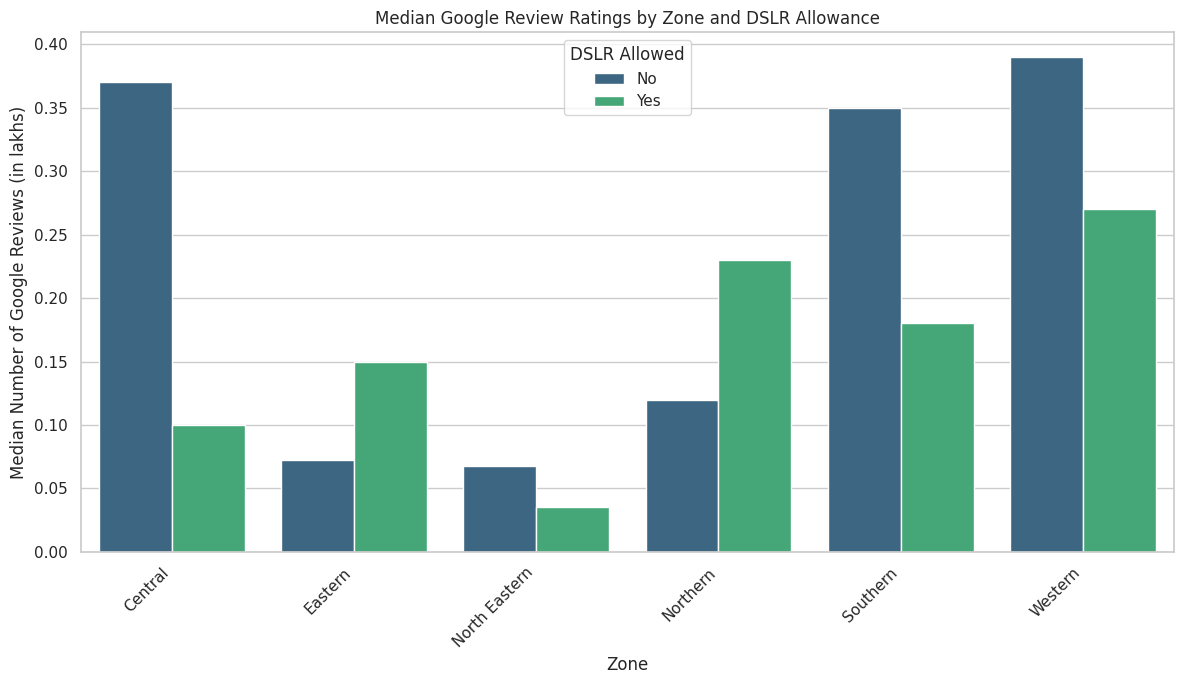

In [10]:
# Calculate the median number of Google reviews for each zone, broken down by DSLR Allowed
median_reviews_by_zone_dslr = df.groupby(['Zone', 'DSLR Allowed'])['Number of google review in lakhs'].median().reset_index()

# Create the barplot
fig, ax = plt.subplots(figsize=(12, 7))
sns.barplot(
    data=median_reviews_by_zone_dslr,
    x='Zone',
    y='Number of google review in lakhs',
    hue='DSLR Allowed',
    errorbar=None, # Turn off error bars as requested
    palette='viridis',
    ax=ax
)

ax.set_title('Median Google Review Ratings by Zone and DSLR Allowance')
ax.set_xlabel('Zone')
ax.set_ylabel('Median Number of Google Reviews (in lakhs)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='DSLR Allowed')
plt.tight_layout()
plt.show()

In [11]:
# Identify the zone from the options below which has a higher median number of ratings at tourist spots where DSLRs are allowed than in those where they are not.
# Pivot the table to easily compare 'Yes' and 'No' medians for each zone
pivot_table = median_reviews_by_zone_dslr.pivot(index='Zone', columns='DSLR Allowed', values='Number of google review in lakhs')

zone_with_higher_dslr_allowed_median = None
for zone in pivot_table.index:
    # Ensure both 'Yes' and 'No' columns exist for comparison
    if 'Yes' in pivot_table.columns and 'No' in pivot_table.columns:
        if pivot_table.loc[zone, 'Yes'] > pivot_table.loc[zone, 'No']:
            zone_with_higher_dslr_allowed_median = zone
            break

print(f"The zone with a higher median number of ratings at tourist spots where DSLRs are allowed than in those where they are not is: {zone_with_higher_dslr_allowed_median}")

The zone with a higher median number of ratings at tourist spots where DSLRs are allowed than in those where they are not is: Eastern


In [13]:
numeric_df = df.select_dtypes(include=['number'])

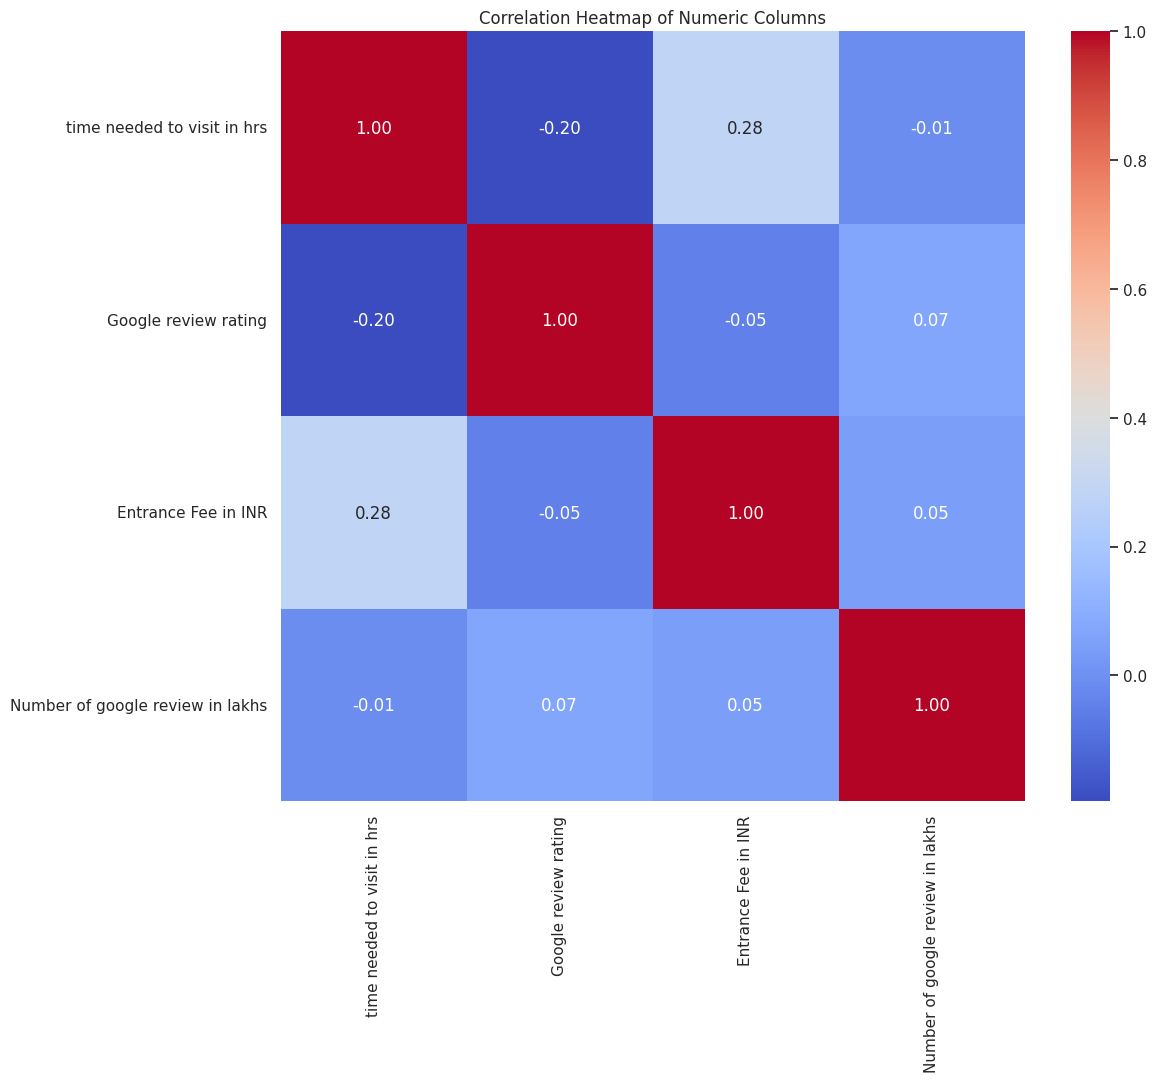

In [14]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Columns')
plt.show()